# EURO STOXX 50: Black–Scholes vs Merton Jump-Diffusion (Monte Carlo)

This notebook builds a fast, presentation-ready empirical comparison between:

- **Black–Scholes / Geometric Brownian Motion (GBM)**
- **Merton Jump-Diffusion**

using **EURO STOXX 50** as the underlying.

## Workflow
1. Download historical EURO STOXX 50 data
2. Estimate a simple GBM model and a simple Merton jump model from returns
3. Simulate both models
4. Compare simulated distributions against real data
5. Compare Monte Carlo option prices


## 0. Abstract
We compare the simulated return distributions and option prices between a standard Black–Scholes diffusion and a Merton jump-diffusion to EURO STOXX 50 returns. We hypothesise that the Merton model is better suited to capturing extreme moves and tail risk, while Black–Scholes is smoother and usually understates discontinuities, because:
- Black–Scholes assumes continuous paths.
- Merton adds random jumps.
- Real equity indices often show fat tails and occasional large moves.


In [1]:
# !pip install yfinance pandas numpy matplotlib scipy seaborn --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, norm
import yfinance as yf

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
np.random.seed(42)

## 1. Obtain EURO STOXX 50 data

We use Yahoo Finance ticker `^STOXX50E` for the EURO STOXX 50 index.


In [3]:
ticker = '^STOXX50E'
start_date = '2018-01-01'
end_date = None

data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data = data[['Close']].dropna().rename(columns={'Close': 'close'})
data['log_return'] = np.log(data['close'] / data['close'].shift(1))
data = data.dropna()

print(data.tail())
print(f'Number of observations: {len(data):,}')

Price             close  log_return
Date                               
2026-06-29  6231.629883    0.001619
2026-06-30  6328.089844    0.015361
2026-07-01  6282.500000   -0.007230
2026-07-02  6360.470215    0.012334
2026-07-03  6412.680176    0.008175
Number of observations: 2,132


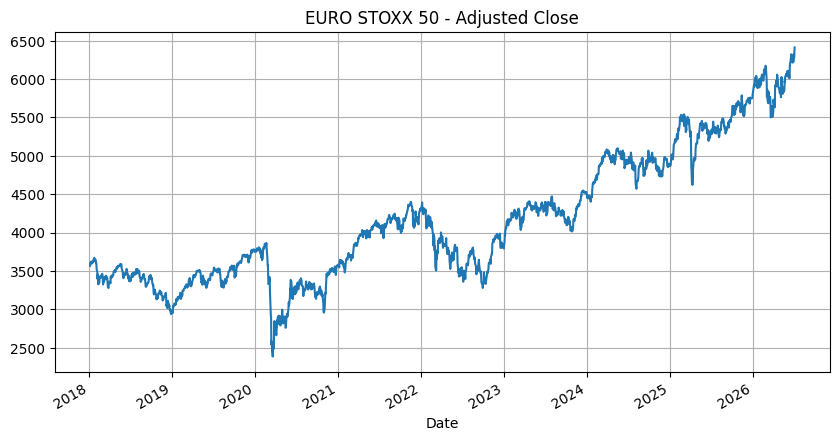

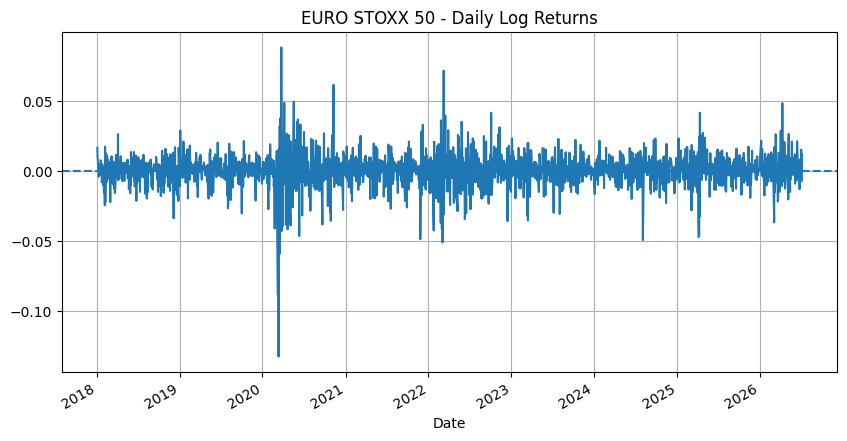

In [4]:
data['close'].plot(title='EURO STOXX 50 - Adjusted Close')
plt.show()

data['log_return'].plot(title='EURO STOXX 50 - Daily Log Returns')
plt.axhline(0, linestyle='--')
plt.show()

## 2. Quick empirical diagnostics

See how the data behaves


In [5]:
r = data['log_return'].dropna()

summary = pd.Series({
    'mean_daily': r.mean(),
    'std_daily': r.std(),
    'mean_annualized': r.mean() * 252,
    'vol_annualized': r.std() * np.sqrt(252),
    'skewness': skew(r, bias=False),
    'excess_kurtosis': kurtosis(r, fisher=True, bias=False),
    'min_daily_return': r.min(),
    'max_daily_return': r.max(),
})

summary

mean_daily           0.000283
std_daily            0.011932
mean_annualized      0.071238
vol_annualized       0.189415
skewness            -0.854283
excess_kurtosis     12.589703
min_daily_return    -0.132405
max_daily_return     0.088343
dtype: float64

In [6]:
z = (r - r.mean()) / r.std()
tail_stats = pd.Series({
    '|z| > 2': (np.abs(z) > 2).mean(),
    '|z| > 3': (np.abs(z) > 3).mean(),
    '|z| > 4': (np.abs(z) > 4).mean(),
})
tail_stats

|z| > 2    0.045497
|z| > 3    0.017355
|z| > 4    0.006098
dtype: float64

## 3. Parameter estimation

### 3.1 Black–Scholes / GBM
For the GBM benchmark we only need:
- annual drift `mu_bs`
- annual volatility `sigma_bs`

### 3.2 Merton Jump-Diffusion
We use a **simple heuristic calibration**:
- classify very large daily returns as jumps
- estimate jump intensity from how often they occur
- estimate jump mean and jump volatility from the identified jump returns
- estimate diffusive volatility from non-jump days



In [7]:
# --- Black-Scholes / GBM parameters ---
mu_bs = r.mean() * 252
sigma_bs = r.std() * np.sqrt(252)

print('GBM annual drift mu      =', round(mu_bs, 6))
print('GBM annual volatility sigma =', round(sigma_bs, 6))

GBM annual drift mu      = 0.071238
GBM annual volatility sigma = 0.189415


In [8]:
# --- Merton return-based heuristic jump identification ---

jump_threshold = 2.5
daily_mean = r.mean()
daily_std = r.std()

jump_mask = np.abs(r - daily_mean) > jump_threshold * daily_std
jump_returns = r[jump_mask]
diff_returns = r[~jump_mask]

years = len(r) / 252
lam = jump_mask.sum() / years  # annual jump intensity
mu_j = jump_returns.mean() if len(jump_returns) > 0 else 0.0
sigma_j = jump_returns.std() if len(jump_returns) > 1 else 0.01
sigma_diff = diff_returns.std() * np.sqrt(252)
mu_merton = r.mean() * 252

merton_params = pd.Series({
    'annual_drift_mu': mu_merton,
    'diffusive_vol_sigma': sigma_diff,
    'jump_intensity_lambda': lam,
    'jump_mean_mu_j': mu_j,
    'jump_std_sigma_j': sigma_j,
    'jump_days_detected': int(jump_mask.sum())
})
merton_params

annual_drift_mu           0.071238
diffusive_vol_sigma       0.146971
jump_intensity_lambda     6.973734
jump_mean_mu_j           -0.013392
jump_std_sigma_j          0.044421
jump_days_detected       59.000000
dtype: float64

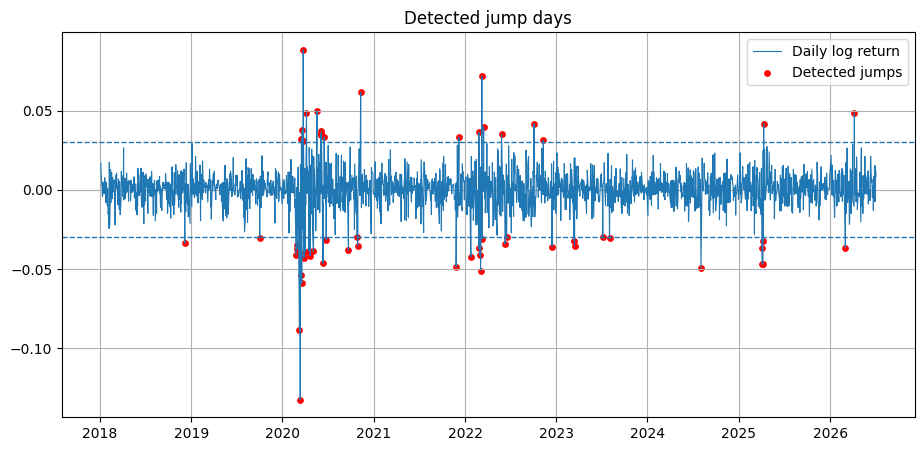

In [9]:
plt.figure(figsize=(11,5))
plt.plot(r.index, r.values, label='Daily log return', linewidth=0.8)
plt.scatter(jump_returns.index, jump_returns.values, color='red', s=15, label='Detected jumps')
plt.axhline(daily_mean + jump_threshold * daily_std, linestyle='--', linewidth=1)
plt.axhline(daily_mean - jump_threshold * daily_std, linestyle='--', linewidth=1)
plt.title('Detected jump days')
plt.legend()
plt.show()

## 4. Simulation functions

We simulate both models under the  empirical measure for distribution comparison.

- GBM uses only drift + diffusion.
- Merton uses drift + diffusion + Poisson jump arrivals.


In [10]:
def simulate_gbm_paths(S0, mu, sigma, T, steps, n_paths, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / steps
    Z = rng.normal(size=(steps, n_paths))
    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.vstack([np.zeros(n_paths), np.cumsum(increments, axis=0)])
    return S0 * np.exp(log_paths)

def simulate_merton_paths(S0, mu, sigma, lam, mu_j, sigma_j, T, steps, n_paths, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / steps

    Z = rng.normal(size=(steps, n_paths))
    N = rng.poisson(lam * dt, size=(steps, n_paths))

    jump_component = np.zeros((steps, n_paths))
    positive = N > 0
    jump_component[positive] = rng.normal(loc=N[positive] * mu_j, scale=np.sqrt(N[positive]) * sigma_j)

    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z + jump_component
    log_paths = np.vstack([np.zeros(n_paths), np.cumsum(increments, axis=0)])
    return S0 * np.exp(log_paths)

## 5. One-year path simulation

We simulate **1 year = 252 trading days**.


In [11]:
S0 = float(data['close'].iloc[-1])
T = 1.0
steps = 252
n_paths_plot = 30
n_paths_mc = 20000

gbm_paths_plot = simulate_gbm_paths(S0, mu_bs, sigma_bs, T, steps, n_paths_plot, seed=42)
merton_paths_plot = simulate_merton_paths(S0, mu_merton, sigma_diff, lam, mu_j, sigma_j, T, steps, n_paths_plot, seed=42)

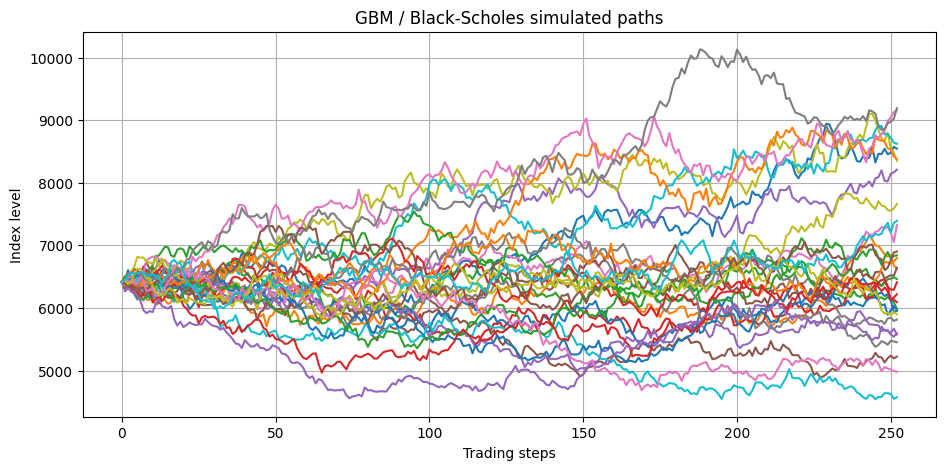

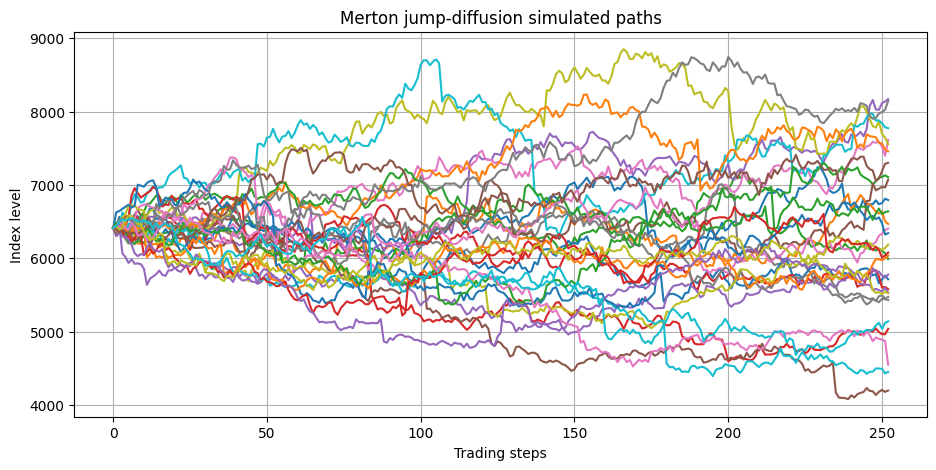

In [12]:
plt.figure(figsize=(11,5))
plt.plot(gbm_paths_plot)
plt.title('GBM / Black-Scholes simulated paths')
plt.xlabel('Trading steps')
plt.ylabel('Index level')
plt.show()

plt.figure(figsize=(11,5))
plt.plot(merton_paths_plot)
plt.title('Merton jump-diffusion simulated paths')
plt.xlabel('Trading steps')
plt.ylabel('Index level')
plt.show()

## 6. Distribution comparison: real data vs GBM vs Merton

To make the comparison fair, we compare **daily log returns**:
- real daily returns
- one-step GBM simulated returns
- one-step Merton simulated returns


In [13]:
def simulate_one_day_gbm_returns(mu, sigma, n_sims, seed=42):
    rng = np.random.default_rng(seed)
    dt = 1/252
    return (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * rng.normal(size=n_sims)

def simulate_one_day_merton_returns(mu, sigma, lam, mu_j, sigma_j, n_sims, seed=42):
    rng = np.random.default_rng(seed)
    dt = 1/252

    Z = rng.normal(size=n_sims)
    N = rng.poisson(lam * dt, size=n_sims)

    jump_component = np.zeros(n_sims)
    positive = N > 0
    jump_component[positive] = rng.normal(loc=N[positive] * mu_j, scale=np.sqrt(N[positive]) * sigma_j)

    return (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z + jump_component

gbm_daily_sim = simulate_one_day_gbm_returns(mu_bs, sigma_bs, len(r)*5, seed=7)
merton_daily_sim = simulate_one_day_merton_returns(mu_merton, sigma_diff, lam, mu_j, sigma_j, len(r)*5, seed=7)

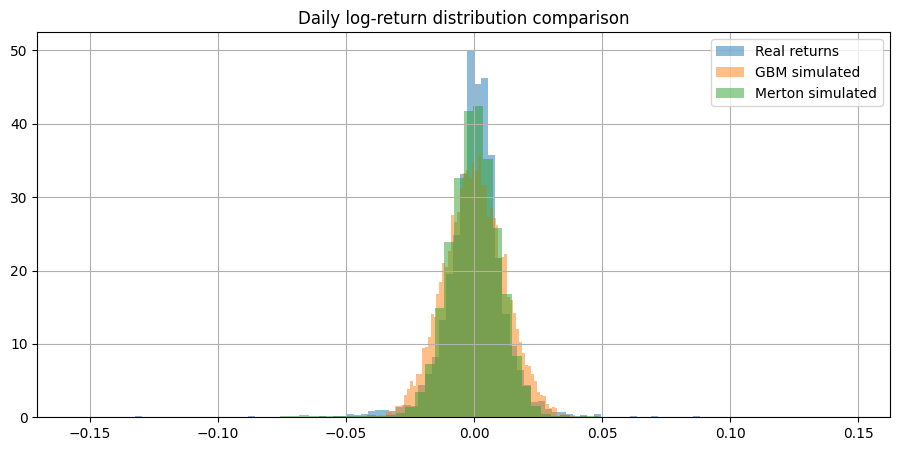

In [14]:
plt.figure(figsize=(11,5))
plt.hist(r, bins=80, density=True, alpha=0.5, label='Real returns')
plt.hist(gbm_daily_sim, bins=80, density=True, alpha=0.5, label='GBM simulated')
plt.hist(merton_daily_sim, bins=80, density=True, alpha=0.5, label='Merton simulated')
plt.title('Daily log-return distribution comparison')
plt.legend()
plt.show()

In [15]:
def diagnostics(x):
    return pd.Series({
        'mean': np.mean(x),
        'std': np.std(x, ddof=1),
        'skewness': skew(x, bias=False),
        'excess_kurtosis': kurtosis(x, fisher=True, bias=False),
        '|z|>3 share': (np.abs((x - np.mean(x)) / np.std(x, ddof=1)) > 3).mean()
    })

comparison_table = pd.DataFrame({
    'Real': diagnostics(r),
    'GBM sim': diagnostics(gbm_daily_sim),
    'Merton sim': diagnostics(merton_daily_sim)
}).T

comparison_table

,mean,std,skewness,excess_kurtosis,|z|>3 share
Real,0.000283,0.011932,-0.854283,12.589703,0.017355
GBM sim,0.000096,0.011898,0.013863,0.006554,0.002814
Merton sim,-0.000369,0.012210,-1.561522,21.674850,0.012570


## 7. Option pricing comparison by Monte Carlo

Now we switch to **risk-neutral pricing** for a 1-year European call.

### Important distinction

- The previous section used **historical / empirical** drift for return-shape comparison.
- Option pricing should use **risk-neutral drift**.

For GBM under risk-neutral pricing with a continuous dividend yield \(q\):

$$
\frac{dS_t}{S_t} = (r-q)\,dt + \sigma\,dW_t^Q
$$

equivalently,

$$
dS_t = (r-q)S_t\,dt + \sigma S_t\,dW_t^Q
$$

For Merton under risk-neutral pricing with a continuous dividend yield \(q\):

$$
\frac{dS_t}{S_{t^-}} = (r-q-\lambda\kappa)\,dt + \sigma\,dW_t^Q + (J-1)\,dN_t
$$

where

$$
\kappa = \mathbb{E}[J-1] = e^{\mu_J + \tfrac{1}{2}\sigma_J^2} - 1
$$

The term $-\lambda\kappa$ is the jump compensator, while $-q$ reflects the dividend yield of the index.

In [16]:
def bs_call_closed_form(S0, K, T, r, q, sigma):
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def merton_call_closed_form(S0, K, T, r, q, sigma, lam, mu_j, sigma_j, n_terms=50):
    # Merton series representation under lognormal jumps
    price = 0.0
    kappa = np.exp(mu_j + 0.5 * sigma_j**2) - 1.0

    for n in range(n_terms):
        poisson_weight = np.exp(-lam * T) * (lam * T)**n / math.factorial(n)
        sigma_n = np.sqrt(sigma**2 + n * sigma_j**2 / T)
        S_n = S0 * np.exp(-lam * kappa * T + n * mu_j + 0.5 * n * sigma_j**2)
        price += poisson_weight * bs_call_closed_form(S_n, K, T, r, q, sigma_n)
    return price

In [17]:
def mc_call_price_gbm(S0, K, T, r, q, sigma, n_paths=100000, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.normal(size=n_paths)
    ST = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0.0)
    disc_payoff = np.exp(-r * T) * payoff
    price = disc_payoff.mean()
    se = disc_payoff.std(ddof=1) / np.sqrt(n_paths)
    return price, se

def mc_call_price_merton(S0, K, T, r, q, sigma, lam, mu_j, sigma_j, n_paths=100000, seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.normal(size=n_paths)
    N = rng.poisson(lam * T, size=n_paths)

    jump_sum = np.zeros(n_paths)
    positive = N > 0
    jump_sum[positive] = rng.normal(loc=N[positive] * mu_j, scale=np.sqrt(N[positive]) * sigma_j)

    kappa = np.exp(mu_j + 0.5 * sigma_j**2) - 1.0
    ST = S0 * np.exp((r - q - lam * kappa - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z + jump_sum)

    payoff = np.maximum(ST - K, 0.0)
    disc_payoff = np.exp(-r * T) * payoff
    price = disc_payoff.mean()
    se = disc_payoff.std(ddof=1) / np.sqrt(n_paths)
    return price, se

In [18]:
# simple 1Y ATM European call
risk_free_rate = 0.03
dividend_yield = 0.02   # constant continuous dividend yield, illustrative assumption
K = S0
T = 1.0

bs_cf = bs_call_closed_form(S0, K, T, risk_free_rate, dividend_yield, sigma_bs)
bs_mc, bs_mc_se = mc_call_price_gbm(S0, K, T, risk_free_rate, dividend_yield, sigma_bs, n_paths=200000, seed=1)

merton_cf = merton_call_closed_form(S0, K, T, risk_free_rate, dividend_yield, sigma_diff, lam, mu_j, sigma_j, n_terms=50)
merton_mc, merton_mc_se = mc_call_price_merton(S0, K, T, risk_free_rate, dividend_yield, sigma_diff, lam, mu_j, sigma_j, n_paths=200000, seed=1)

option_table = pd.DataFrame({
    'Model': ['Black-Scholes', 'Black-Scholes', 'Merton', 'Merton'],
    'Method': ['Closed form', 'Monte Carlo', 'Closed form', 'Monte Carlo'],
    'Call Price': [bs_cf, bs_mc, merton_cf, merton_mc],
    'MC Std. Error': [np.nan, bs_mc_se, np.nan, merton_mc_se]
})

option_table_display = option_table.copy()
option_table_display["MC Std. Error"] = option_table_display["MC Std. Error"].apply(
    lambda x: "—" if pd.isna(x) else f"{x:.4f}"
)
option_table_display["Call Price"] = option_table_display["Call Price"].map(lambda x: f"{x:.4f}")

option_table

,Model,Method,Call Price,MC Std. Error
0,Black-Scholes,Closed form,503.842264,NaN
1,Black-Scholes,Monte Carlo,500.945369,1.781058
2,Merton,Closed form,505.897600,NaN
3,Merton,Monte Carlo,504.209037,1.769390


## 8. Conclusion

After running Monte Carlo simulations on both the GBM and Merton models, we derive the following analysis:

1. **Historical EURO STOXX 50 returns are not perfectly normal.**  
   The series shows non-zero skewness, excess kurtosis, and a non-trivial proportion of large daily moves.

2. **GBM reproduces the center of the return distribution reasonably well but tends to smooth out extremes.**  
   This is expected because GBM assumes continuous paths and Gaussian shocks only.

3. **Merton better captures tail events.**  
   Because it adds Poisson-driven jumps, the simulated return distribution can exhibit fatter tails and more large moves.

4. **Option prices under Merton are often above Black–Scholes prices when jump risk is material.**  
   This happens because jumps add payoff-relevant uncertainty, especially for convex instruments like options.

5. **Caveat:** the Merton parameters used here are obtained through a return-based heuristic parameterization, not full maximum likelihood or full option-surface calibration.  
    The purpose of this appendix is illustrative: to provide a transparent numerical comparison between the diffusion benchmark and the jump-diffusion extension.